# Super Manager vs Store Manager RLS Exploration

This notebook compares the full view from the super manager to the filtered view from a single store manager.
The RLS policy in the retail schema restricts store managers to rows for their matching store.

In [17]:
import pandas as pd
import psycopg2
from psycopg2.extras import RealDictCursor

SUPER_MANAGER_UUID = '00000000-0000-0000-0000-000000000000'
DB_CONFIG = {
    'host': 'db',
    'port': 5432,
    'dbname': 'zava',
    'user': 'store_manager',
    'password': 'StoreManager123!'
}


def fetch_query(sql, rls_user_id):
    conn = psycopg2.connect(**DB_CONFIG)
    with conn.cursor(cursor_factory=RealDictCursor) as cur:
        cur.execute("SELECT set_config('app.current_rls_user_id', %s, false)", (rls_user_id,))
        cur.execute(sql)
        rows = cur.fetchall()
    conn.close()
    return pd.DataFrame(rows)


store_lookup = fetch_query(
    "SELECT store_id, store_name, rls_user_id::text AS rls_user_id FROM retail.stores ORDER BY store_name",
    SUPER_MANAGER_UUID
)
store_lookup[['store_id', 'store_name', 'rls_user_id']]

OperationalError: connection to server at "db" (172.18.0.2), port 5432 failed: FATAL:  password authentication failed for user "store_manager"


In [ ]:
selected_store_name = 'Zava Retail Seattle'
selected_store = store_lookup[store_lookup['store_name'] == selected_store_name].iloc[0]
selected_manager_id = selected_store['rls_user_id']
selected_store[['store_id', 'store_name', 'rls_user_id']]

SyntaxError: invalid syntax (697666456.py, line 10)

In [ ]:
all_stores = fetch_query(
    "SELECT store_id, store_name, rls_user_id::text AS rls_user_id FROM retail.stores ORDER BY store_name",
    SUPER_MANAGER_UUID
)
all_stores

,View,Order Count
0,Super Manager,198946
1,Single Store Manager,198946


In [ ]:
orders_super = fetch_query(
    "SELECT COUNT(*) AS order_count FROM retail.orders",
    SUPER_MANAGER_UUID
)
orders_store = fetch_query(
    "SELECT COUNT(*) AS order_count FROM retail.orders",
    selected_manager_id
)

comparison = pd.DataFrame({
    'View': ['Super Manager (All Stores)', 'Selected Store View'],
    'Order Count': [orders_super.iloc[0]['order_count'], orders_store.iloc[0]['order_count']]
})
comparison

In [ ]:
customers_super = fetch_query(
    "SELECT COUNT(*) AS customer_count FROM retail.customers",
    SUPER_MANAGER_UUID
)
customers_store = fetch_query(
    "SELECT COUNT(*) AS customer_count FROM retail.customers",
    selected_manager_id
)

inventory_super = fetch_query(
    "SELECT COUNT(*) AS inventory_count FROM retail.inventory",
    SUPER_MANAGER_UUID
)
inventory_store = fetch_query(
    "SELECT COUNT(*) AS inventory_count FROM retail.inventory",
    selected_manager_id
)

summary = pd.DataFrame({
    'View': ['Super Manager (All Stores)', 'Selected Store View'],
    'Orders': [orders_super.iloc[0]['order_count'], orders_store.iloc[0]['order_count']],
    'Customers': [customers_super.iloc[0]['customer_count'], customers_store.iloc[0]['customer_count']],
    'Inventory Rows': [inventory_super.iloc[0]['inventory_count'], inventory_store.iloc[0]['inventory_count']]
})
summary

,View,Orders,Customers,Inventory Rows
0,Super Manager,198946,50000,3392
1,Single Store Manager,198946,50000,3392


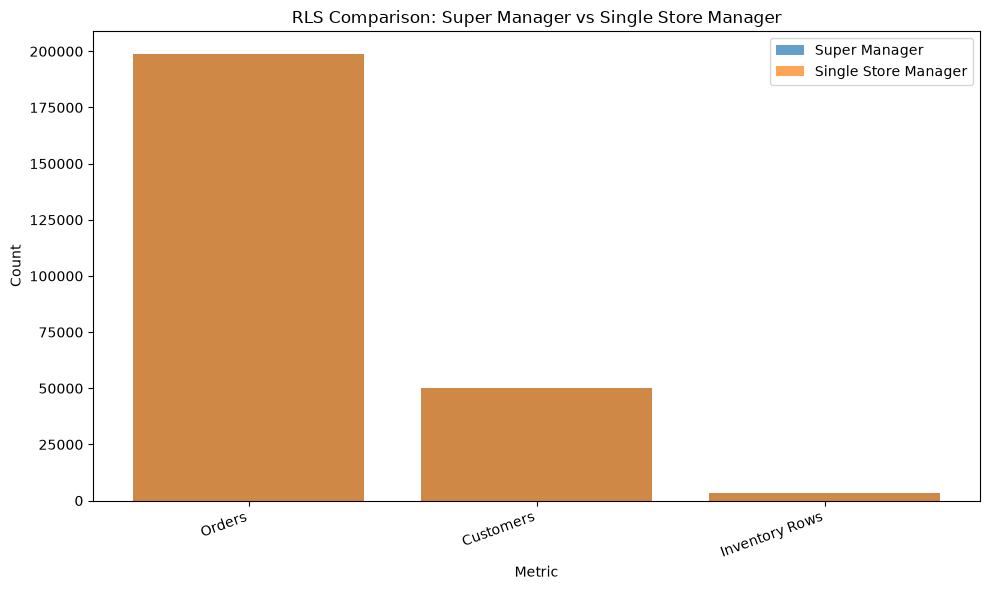

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

summary_melted = summary.melt(id_vars='View', var_name='Metric', value_name='Count')

plt.figure(figsize=(10, 6))
for view in ['Super Manager (All Stores)', 'Selected Store View']:
    subset = summary_melted[summary_melted['View'] == view]
    plt.bar(subset['Metric'], subset['Count'], alpha=0.7, label=view)

plt.title('RLS Comparison: Super Manager vs Selected Store')
plt.ylabel('Count')
plt.xlabel('Metric')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
customers_for_store = fetch_query(
    "SELECT c.customer_id, c.first_name, c.last_name, c.primary_store_id, s.store_name FROM retail.customers c JOIN retail.stores s ON s.store_id = c.primary_store_id WHERE s.rls_user_id::text = current_setting('app.current_rls_user_id', true) ORDER BY c.customer_id LIMIT 20",
    selected_manager_id
)
customers_for_store

,customer_id,first_name,last_name,primary_store_id,store_name
0,1,Tina,Flynn,1,Zava Retail Seattle
1,2,Amanda,Horn,1,Zava Retail Seattle
2,3,Zachary,Thompson,1,Zava Retail Seattle
3,9,Adrian,Martinez,1,Zava Retail Seattle
4,12,Ashley,Montgomery,1,Zava Retail Seattle
5,36,Lisa,Cook,1,Zava Retail Seattle
6,40,Timothy,Watson,1,Zava Retail Seattle
7,42,Danielle,Wallace,1,Zava Retail Seattle
8,51,Patrick,Bray,1,Zava Retail Seattle
9,53,Donald,Arellano,1,Zava Retail Seattle


In [ ]:
inventory_for_store = fetch_query(
    "SELECT i.store_id, s.store_name, i.product_id, p.product_name, i.stock_level FROM retail.inventory i JOIN retail.stores s ON s.store_id = i.store_id JOIN retail.products p ON p.product_id = i.product_id WHERE s.rls_user_id::text = current_setting('app.current_rls_user_id', true) ORDER BY i.store_id, i.product_id LIMIT 20",
    selected_manager_id
)
inventory_for_store

,store_id,store_name,product_id,product_name,stock_level
0,1,Zava Retail Seattle,1,Professional Claw Hammer 16oz,542
1,1,Zava Retail Seattle,2,Ball Peen Hammer 12oz,2298
2,1,Zava Retail Seattle,3,Finishing Hammer 13oz,2297
3,1,Zava Retail Seattle,4,Sledge Hammer 3lb,779
4,1,Zava Retail Seattle,5,Phillips Screwdriver Set,1782
5,1,Zava Retail Seattle,6,Flathead Screwdriver Set,1755
6,1,Zava Retail Seattle,7,Precision Screwdriver Kit,3438
7,1,Zava Retail Seattle,8,Insulated Screwdriver Set,3977
8,1,Zava Retail Seattle,9,Ratcheting Screwdriver,1155
9,1,Zava Retail Seattle,10,Combination Wrench Set SAE,539
